In [ ]:
%pip install -e ..

In [7]:
from pathlib import Path
from research_core.classes import AnalyseMarket, helpers

# ─────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────

ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"

asset = "KGHM"
TICK_SIZE = 0.01

# ─────────────────────────────────────────────────────────────
# For REAL MARKET DATA (empirical order-flow database)
# ─────────────────────────────────────────────────────────────
db_path = OUTPUT_DIR / "KGHM_order_flow.sqlite"

am = AnalyseMarket(db_path, tick_size=TICK_SIZE)

# ─────────────────────────────────────────────────────────────
# For SIMULATION DATA, use the simulation database instead:
#   am = AnalyseMarket("sim_events.sqlite", tick_size=0.01)
# ─────────────────────────────────────────────────────────────

AnalyseMarket | KGHM_order_flow.sqlite | real data
  Tables: ['fills', 'mo_orders', 'orders']


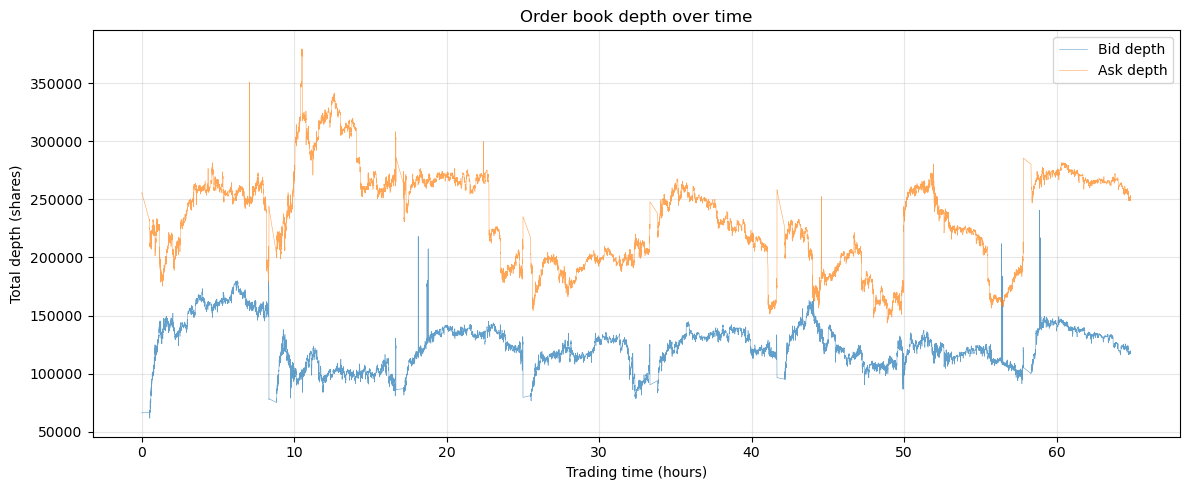

In [3]:
am.plot_depth(n_events=1_000_000, offset=0)

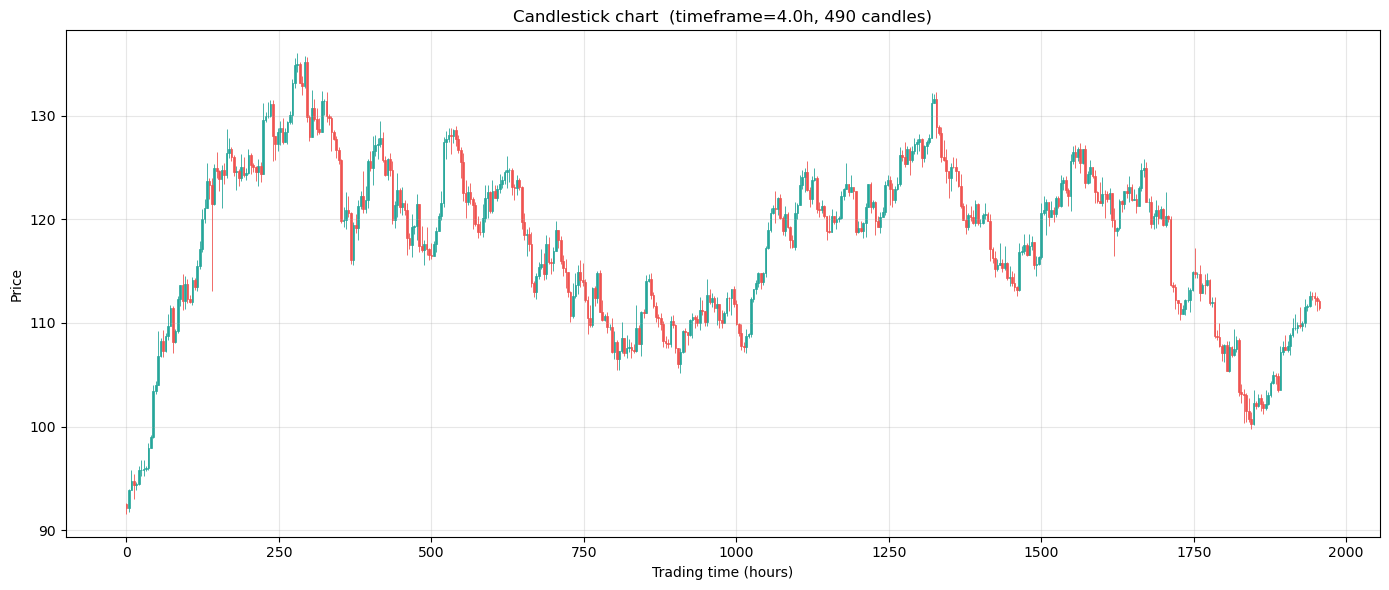

In [3]:
am.plot_candlestick(timeframe=14400.0)

Full sign series length: 661,230 MOs,  buy fraction: 0.513
Power-law exponent:  γ = 0.5285   (ρ(k) ~ k^{-0.5285})


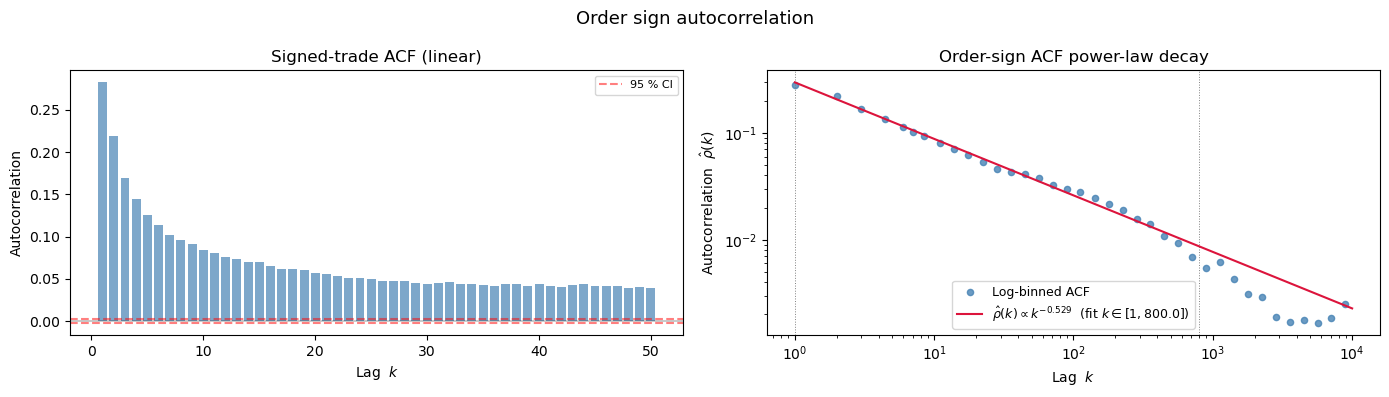

In [4]:
am.stylized_order_sign_autocorrelation(cap=800)

In [ ]:
am.price_impact_propagator(split_regimes=True)

In [9]:
save_path = helpers.data_dir() / "mo_depth_data" / "KGHM_tw_quartiles.npz"
am.ticks_walked_cdfs(save_path=str(save_path))

Q0: P(0)=0.8388,  P(≥5)=0.005970
Q1: P(0)=0.8574,  P(≥5)=0.001440
Q2: P(0)=0.8743,  P(≥5)=0.001119
Q3: P(0)=0.8961,  P(≥5)=0.000575

Saved: C:\Users\jaspe\Documents\CLS\Thesis\research_core\data\mo_depth_data\KGHM_tw_quartiles.npz


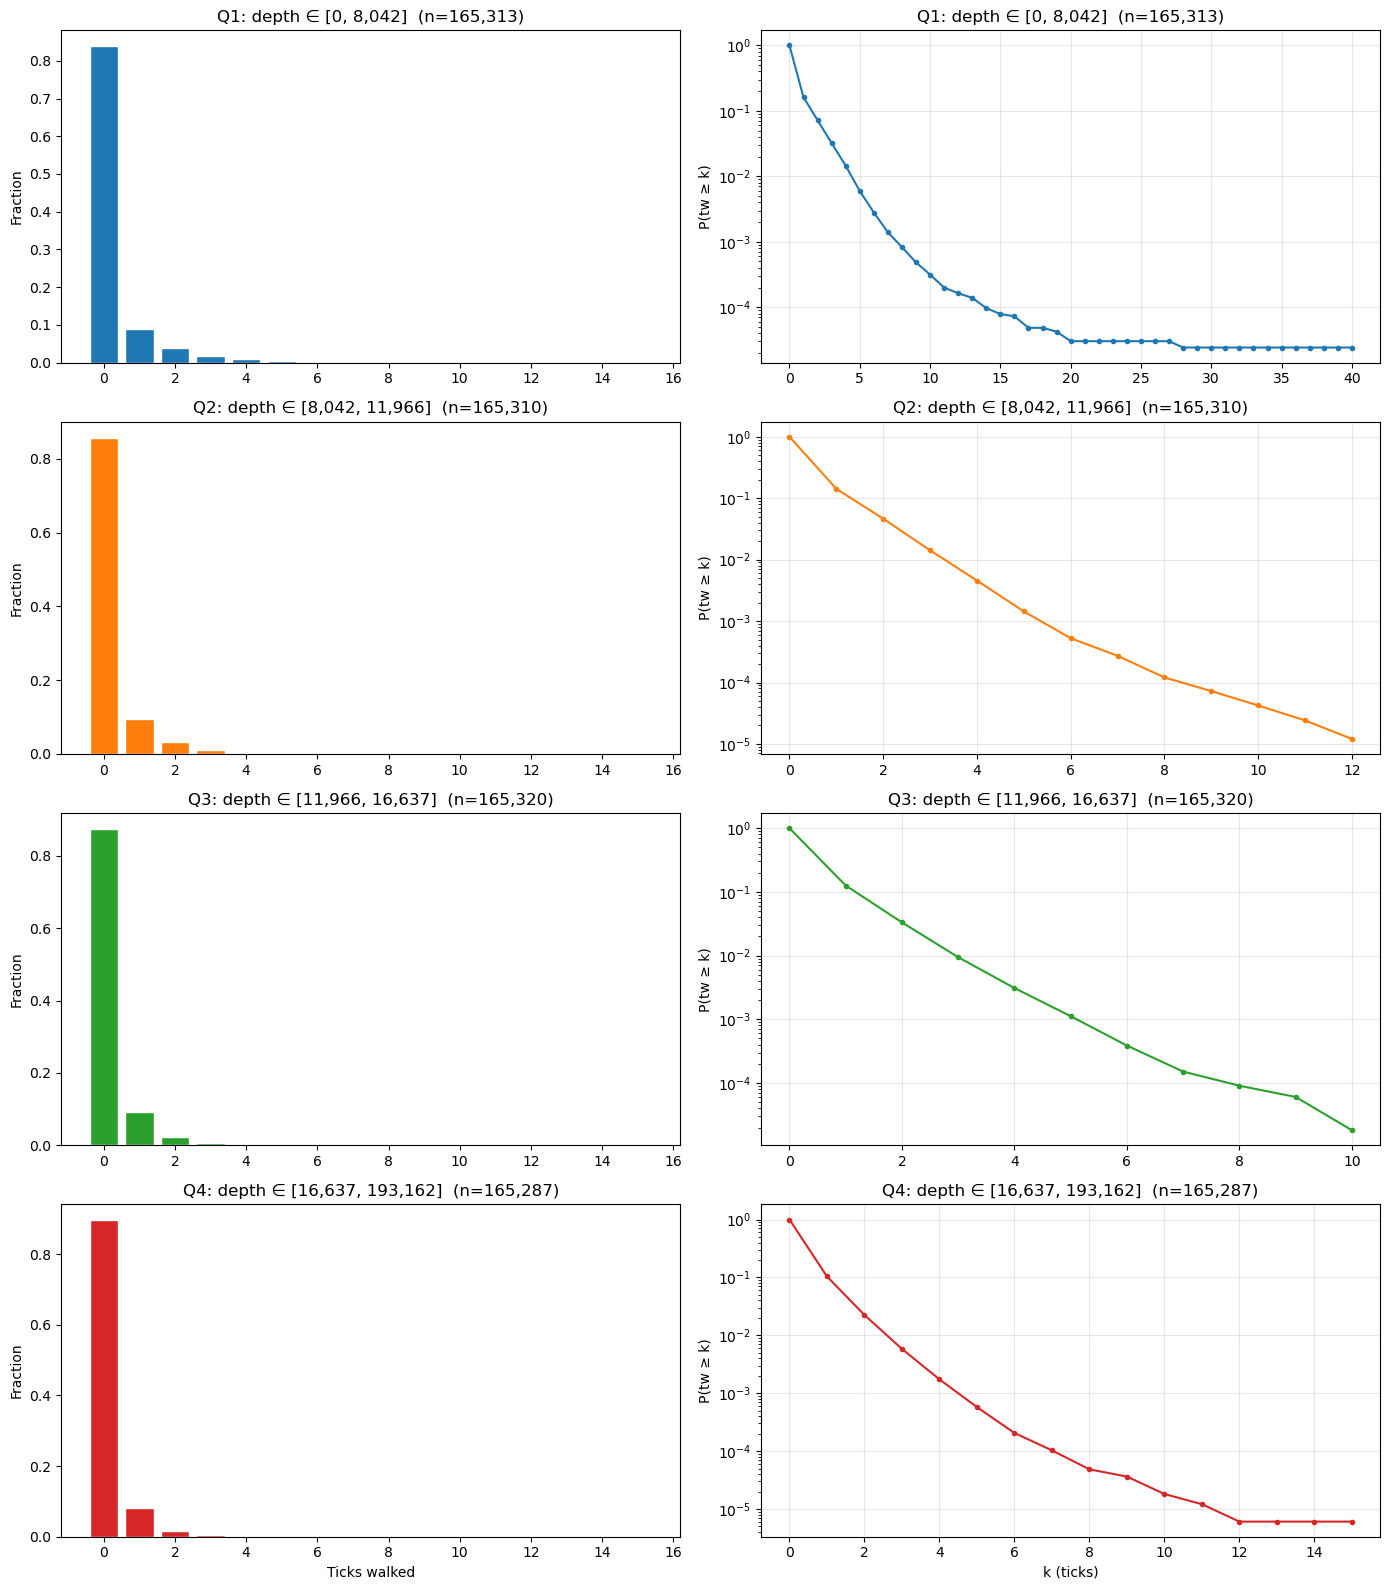


  Quartile         n   mean tw    P(>0)     P(≥5)
──────────────────────────────────────────────────
        Q1   165,313     0.294    16.1%     0.60%
        Q2   165,310     0.210    14.3%     0.14%
        Q3   165,320     0.173    12.6%     0.11%
        Q4   165,287     0.135    10.4%     0.06%


In [10]:
am.price_impact_by_depth()